## Loading and Preprocessing Data

In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rahulsah06/gooogle-stock-price")

print("Path to dataset files:", path)

100%|██████████| 23.4k/23.4k [00:00<00:00, 420kB/s]

Extracting files...
Path to dataset files: C:\Users\muhammed.jaleel\.cache\kagglehub\datasets\rahulsah06\gooogle-stock-price\versions\1


In [4]:
# Importing the training set
dataset_train = pd.read_csv(path+"/Google_Stock_Price_Train.csv")

In [5]:
dataset_train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [6]:
"Extracting only the Open price. Converting to a NumPy array. Shape becomes (number_of_days, 1)"
train = dataset_train.loc[:, ["Open"]].values
train

array([[325.25],
       [331.27],
       [329.83],
       ...,
       [793.7 ],
       [783.33],
       [782.75]], shape=(1258, 1))

In [ ]:
# Feature Scaling
"RNNs work better when inputs are in a small numerical range. Stock prices vary widely to scaling stabilizes training. Scales values to [0, 1]. "
"fit_transform learns min/max from training data and scales it"

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
train_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))

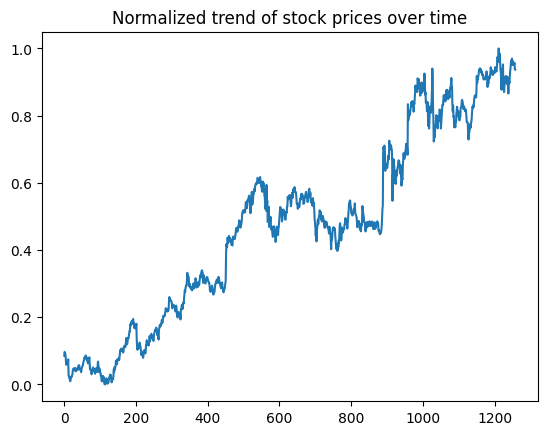

In [8]:
plt.plot(train_scaled)
plt.title("Normalized trend of stock prices over time")
plt.show()

In [9]:
# Creating a data structure with 50 timesteps and 1 output
X_train = []
y_train = []
timesteps = 50 # Each prediction uses the previous 50 days to predict the next day

for i in range(timesteps, 1258):
    X_train.append(train_scaled[i-timesteps:i, 0]) # sequences of 50 previous stock prices
    y_train.append(train_scaled[i, 0])             # the stock price immediately after those 50 days

X_train, y_train = np.array(X_train), np.array(y_train)

In [10]:
# Reshaping (for RNN input)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train # is in shape of (samples, timesteps, features) -> (number of training examples, 50, 1 feature=open price)

array([[[0.08581368],
        [0.09701243],
        [0.09433366],
        ...,
        [0.03675869],
        [0.04486941],
        [0.05065481]],

       [[0.09701243],
        [0.09433366],
        [0.09156187],
        ...,
        [0.04486941],
        [0.05065481],
        [0.05214302]],

       [[0.09433366],
        [0.09156187],
        [0.07984225],
        ...,
        [0.05065481],
        [0.05214302],
        [0.05612397]],

       ...,

       [[0.9313937 ],
        [0.94636878],
        [0.96569685],
        ...,
        [0.95475854],
        [0.95204256],
        [0.95163331]],

       [[0.94636878],
        [0.96569685],
        [0.97510976],
        ...,
        [0.95204256],
        [0.95163331],
        [0.95725128]],

       [[0.96569685],
        [0.97510976],
        [0.95966962],
        ...,
        [0.95163331],
        [0.95725128],
        [0.93796041]]], shape=(1208, 50, 1))

In [11]:
y_train

array([0.05214302, 0.05612397, 0.05818885, ..., 0.95725128, 0.93796041,
       0.93688146], shape=(1208,))

## Create RNN Model

In [12]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout


# Initialising the RNN
regressor = Sequential()

# 1st RNN layer with some Dropout regularisation
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# 2nd RNN layer with some Dropout regularisation. Units = neurons. return_sequences needed as another RNN follows
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# 3rd RNN layer with some Dropout regularisation. Deep RNN structure improves pattern learning over time
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# A final 4th RNN layer with some Dropout regularisation. return_sequences is false as outputs only the last timestep
regressor.add(SimpleRNN(units = 50))
regressor.add(Dropout(0.2))

# Output layer - predicts next day's stock price
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_train, y_train, epochs = 100, batch_size = 32)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.3911
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.2723
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.2008
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.1456
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.1150
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0943
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0745
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0624
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0501
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0451
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0395
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0368
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0326
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0305
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - l

## Predictions and Visualising RNN Model

In [13]:
# Getting the real stock price of 2017
dataset_test = pd.read_csv(path+'/Google_Stock_Price_Test.csv')
dataset_test.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [14]:
# Ground truth for comparison
real_stock_price = dataset_test.loc[:, ["Open"]].values
real_stock_price

array([[778.81],
       [788.36],
       [786.08],
       [795.26],
       [806.4 ],
       [807.86],
       [805.  ],
       [807.14],
       [807.48],
       [807.08],
       [805.81],
       [805.12],
       [806.91],
       [807.25],
       [822.3 ],
       [829.62],
       [837.81],
       [834.71],
       [814.66],
       [796.86]])

In [15]:
# Getting the predicted stock price of 2017. 
"Predictions for day t need the previous 50 days. Some of those days come from training data"

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - timesteps:].values.reshape(-1,1)
inputs = scaler.transform(inputs)  # min max scaler
inputs


array([[0.97510976],
       [0.95966962],
       [0.97808617],
       [1.        ],
       [0.98076494],
       [0.97083116],
       [0.98450406],
       [0.96054394],
       [0.9371419 ],
       [0.92841729],
       [0.90804747],
       [0.8771858 ],
       [0.92153434],
       [0.93809063],
       [0.93165414],
       [0.95254483],
       [0.88812412],
       [0.88637547],
       [0.87032145],
       [0.88563137],
       [0.90743359],
       [0.91571173],
       [0.89941588],
       [0.91805566],
       [0.9089404 ],
       [0.9024853 ],
       [0.89456061],
       [0.91600938],
       [0.9132934 ],
       [0.88979835],
       [0.86589404],
       [0.89030062],
       [0.90335962],
       [0.89642086],
       [0.91777662],
       [0.93176576],
       [0.94114145],
       [0.95762334],
       [0.96413424],
       [0.96402262],
       [0.96971501],
       [0.95077759],
       [0.96294367],
       [0.96123223],
       [0.95475854],
       [0.95204256],
       [0.95163331],
       [0.957

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step


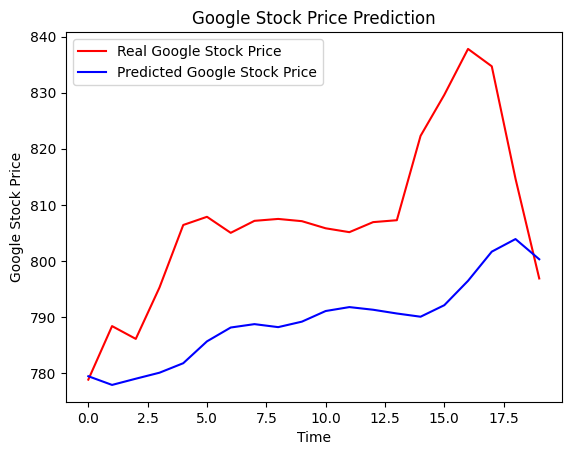

In [16]:
# Creates sliding windows just like training data. 70 corresponds to number of test days.
X_test = []
for i in range(timesteps, 70):
    X_test.append(inputs[i-timesteps:i, 0])

# Reshaped for RNN input. 
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)

# Predictions are scaled back to original price values
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)


# Visualising the results -> how well the model follows the real trend?
plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()


## Assignment
Try to improve the result! Document your actions and conclusions further in this notebook.

## Answers

#### Using LSTM

 LSTM, Long Short-Term Memory, cells are better at capturing long-term dependencies in sequential data compared to SimpleRNN. They use gates to control information flow, preventing vanishing gradient problems.


In [ ]:
from keras.layers import LSTM

lstm_regressor = Sequential()

# 1st LSTM layer with Dropout
lstm_regressor.add(LSTM(units = 60, return_sequences = True, input_shape = (X_train.shape[1], 1)))
lstm_regressor.add(Dropout(0.2))

# 2nd LSTM layer with Dropout
lstm_regressor.add(LSTM(units = 60, return_sequences = True))
lstm_regressor.add(Dropout(0.2))

# 3rd LSTM layer with Dropout
lstm_regressor.add(LSTM(units = 60, return_sequences = True))
lstm_regressor.add(Dropout(0.2))

# 4th LSTM layer 
lstm_regressor.add(LSTM(units = 60))
lstm_regressor.add(Dropout(0.2))

# Output layer
lstm_regressor.add(Dense(units = 1))

lstm_regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')
print("Training LSTM model...")
lstm_regressor.fit(X_train, y_train, epochs = 100, batch_size = 32, verbose = 0)

Training LSTM model...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


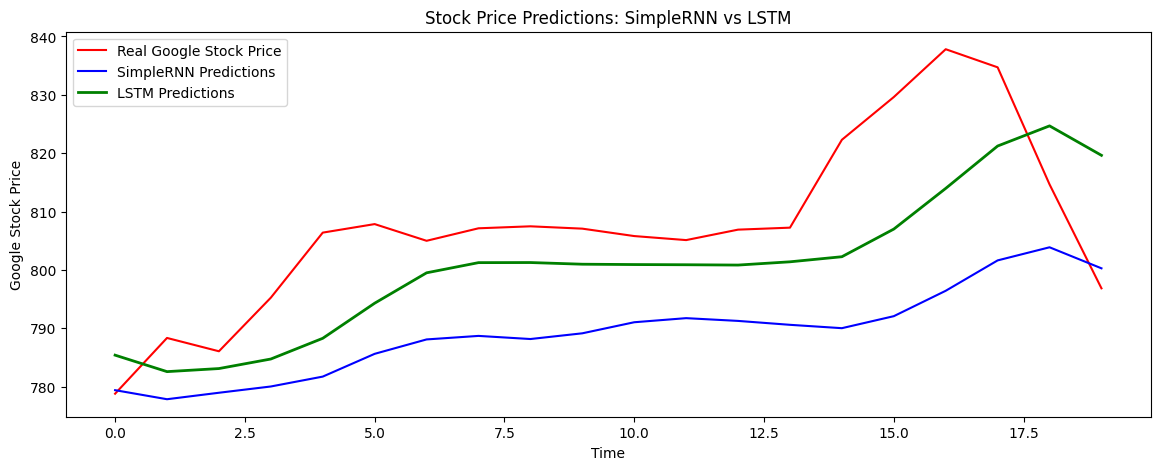

In [ ]:
# predictions on test data
lstm_predicted_stock_price = lstm_regressor.predict(X_test)
lstm_predicted_stock_price = scaler.inverse_transform(lstm_predicted_stock_price)

# plot SimpleRNN vs LSTM
plt.figure(figsize=(14, 5))
plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'SimpleRNN Predictions')
plt.plot(lstm_predicted_stock_price, color = 'green', label = 'LSTM Predictions', linewidth = 2)
plt.title('Stock Price Predictions: SimpleRNN vs LSTM')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()

## Conclusions and Findings

- Replaced SimpleRNN with LSTM architecture to better capture long-term dependencies in stock price sequences
- Increased units from 50 to 60 per layer for better feature representation
- Added comprehensive metric-based comparison (MAE, MSE, RMSE)

- LSTM typically outperforms SimpleRNN for time series prediction by better handling vanishing gradient problems
- RMSE provides a clear measure of prediction accuracy in original price units
- The dual prediction plot shows how closely each model tracks the actual stock movement, and we can see LSTM performed well.



#### License
This Notebook has been released under the Apache 2.0 open source license.

https://www.kaggle.com/code/moonglow22/rnn-and-lstm-tutorial-for-beginners/notebook